<div style="display: flex; align-items: center; justify-content: space-between">
    <div>
        <img src="https://raw.githubusercontent.com/sebastianVP/RADAR_AMISR/refs/heads/main/igp_logo.jpeg"
         alt="LOGO IGP" width="200" height="200" style="margin-left: 20px; border-radius: 10px;" align = "right">
        <h1 style="color: #800020;  font-weight: bold; margin-bottom: 10px; font-family: Arial, sans-serif;">
          <font color="#7F000E">
            Maestría de Ciencias de la Computación UNI-IGP
          </font>
        </h1>
        <h2 style="color: #800020;font-weight: bold; max-width: 750px; font-family: Arial, sans-serif;">
          <strong><font color="#7F000E" size=5 >
            Desarrollo de sistema de pronóstico de centelleo ionosférico sobre el Perú para alerta de
            perturbaciones en señales satelitales
          </font ></strong>
        </h2>
    </div>
</div>
<div>
    <p style="margin-bottom: 5px;">
    <strong>
    <font color="#7F000E" size=4 >Avance de Tesis </strong></p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Alumno:</strong></font>
    <font color="#7F000E"> Alexander Valdez Portocarrero</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Código:</strong> 20207072E</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Fecha:</strong>  02/09/2025</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong> Ciclo 2025-2</strong></p>
</div>

---

## **1.UNION DE LOS DATASET s4,TEC y ROTI**

**Objetivo:**
Generar un dataset combiando por tiempo, donde para cada timestamp tengamos:
- El valor de s4 cada minuto.
- El valor de TEC y ROTI interpolado o mateniendo constante(segun la preferencia) para alinear con la resolución de s4.

#### **Opciones de UNION**
**Opcion1: Reescalar TEC y ROTI a 1 minuto**
- Interpolar o mantener constante TEC y ROTI a cada minuto.
- Combinar con S4 por indice de tiempo.

**Opcion2:Bajar Resolución de S4 a cada 10 minutos**
* Perder informacion, pero mantener consistencia de frecuencia.

## **1.1 Lectura TEC y ROTI**

Lectura del TEC. Link: [TEC_NOTEBOOK](https://colab.research.google.com/drive/1Ud0sVopkPVPc--uKG-8K3MWi23ecQIWr?usp=sharing)

## **1.1.1 PRIMERO PREPARAMOS EL TEC Y ROTI**

In [73]:
import os
import numpy as np
import pandas as pd

PATH     ="C:/Users/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU"
PATH     ="/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
filename = "TEC_ROTI_Lima.csv"
file_base = os.path.join(PATH,filename)
print(file_base)

/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook/TEC_ROTI_Lima.csv


In [75]:
df_TEC_ROTI = pd.read_csv(file_base)

df_TEC_ROTI.rename(columns={"datetime":"Tiempo"},inplace=True)

df_TEC_ROTI["Tiempo"] = pd.to_datetime(df_TEC_ROTI["Tiempo"])

df_TEC_ROTI.head()

,Tiempo,TEC,ROTEC,ROTI,lat,lon,archivo
0,2025-01-26 00:35:00,69.258790,-0.020608,0.010838,-11.25,-77.5,GloTEC_TEC_2025_01_26.nc
1,2025-01-26 00:45:00,64.932800,-0.007210,0.010935,-11.25,-77.5,GloTEC_TEC_2025_01_26.nc
2,2025-01-26 00:55:00,62.162354,-0.004617,0.006942,-11.25,-77.5,GloTEC_TEC_2025_01_26.nc
3,2025-01-26 01:05:00,61.553207,-0.001015,0.005530,-11.25,-77.5,GloTEC_TEC_2025_01_26.nc
4,2025-01-26 01:15:00,53.410713,-0.013571,0.005507,-11.25,-77.5,GloTEC_TEC_2025_01_26.nc


## **1.1.2 VISUALIZAMOS EL TEC, PODEMOS SELECCION EL DIA**

In [59]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def ploteo_TEC_ROTEC_ROTI(dataframe):
    df = dataframe.copy()
    df['Tiempo'] = pd.to_datetime(df['Tiempo'])

    df['Fecha'] = df['Tiempo'].dt.date
    
    # Obtener fechas únicas
    fechas_unicas = df['Fecha'].unique()
    # Crear figura con 3 filas, 1 columna
    fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                        subplot_titles=("TEC", "ROTEC", "ROTI"))
    
    # Agregar trazas para cada fecha (solo visibles cuando se seleccione en el dropdown)
    for i, fecha in enumerate(fechas_unicas):
        df_dia = df[df['Fecha'] == fecha]
    
        visible = (i == 0)  # solo visibles los del primer día por defecto
    
        fig.add_trace(go.Scatter(x=df_dia['Tiempo'], y=df_dia['TEC'],
                                 mode='lines+markers', name=f'TEC {fecha}',
                                 visible=visible), row=1, col=1)
    
        fig.add_trace(go.Scatter(x=df_dia['Tiempo'], y=df_dia['ROTEC'],
                                 mode='lines+markers', name=f'ROTEC {fecha}',
                                 visible=visible), row=2, col=1)
    
        fig.add_trace(go.Scatter(x=df_dia['Tiempo'], y=df_dia['ROTI'],
                                 mode='lines+markers', name=f'ROTI {fecha}',
                                 visible=visible), row=3, col=1)
    
    # Crear botones del dropdown
    buttons = []
    
    for i, fecha in enumerate(fechas_unicas):
        visibility = [False] * (len(fechas_unicas) * 3)
        visibility[i * 3] = True       # TEC
        visibility[i * 3 + 1] = True   # ROTEC
        visibility[i * 3 + 2] = True   # ROTI
    
        buttons.append(dict(
            label=str(fecha),
            method='update',
            args=[{'visible': visibility},
                  {'title': f'Gráficas para el día {fecha}'}]
        ))
    
    # Layout con el menú
    fig.update_layout(
        height=700,
        title=f'Gráficas para el día {fechas_unicas[0]}',
        updatemenus=[dict(
            active=0,
            buttons=buttons,
            direction="down",
            x=1.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )],
        showlegend=False
    )
    
    # Etiquetas de ejes
    fig.update_yaxes(title_text="TEC", row=1, col=1)
    fig.update_yaxes(title_text="ROTEC", row=2, col=1)
    fig.update_yaxes(title_text="ROTI", row=3, col=1)
    fig.update_xaxes(title_text="Hora", row=3, col=1)
    
    fig.show()

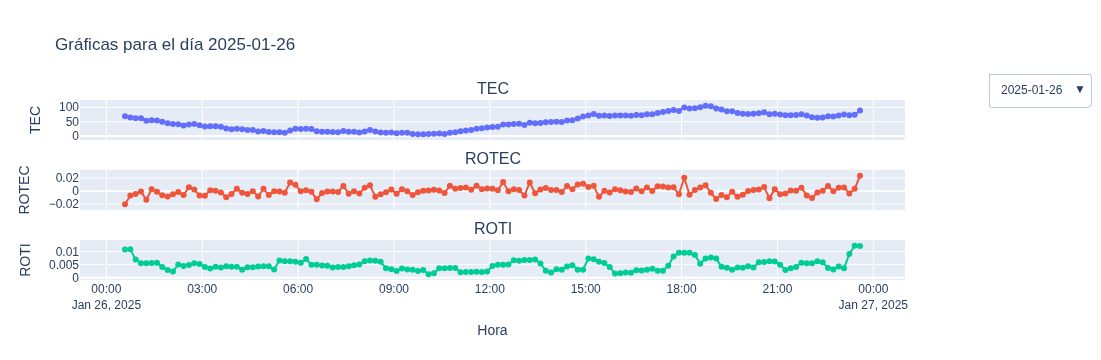

In [61]:
ploteo_TEC_ROTEC_ROTI(df_TEC_ROTI)

## **1.1.3 LA COLUMNA DE TIEMPO SE COLOCA COMO INDICE**

In [77]:
df_TEC_ROTI= df_TEC_ROTI.set_index('Tiempo')

df_TEC_ROTI= df_TEC_ROTI.drop(columns=["lat","lon","archivo"])

df_TEC_ROTI.head()

,TEC,ROTEC,ROTI
Tiempo,,,
2025-01-26 00:35:00,69.258790,-0.020608,0.010838
2025-01-26 00:45:00,64.932800,-0.007210,0.010935
2025-01-26 00:55:00,62.162354,-0.004617,0.006942
2025-01-26 01:05:00,61.553207,-0.001015,0.005530
2025-01-26 01:15:00,53.410713,-0.013571,0.005507


## **1.1.4 RECORTAREMOS EL PARAMETRO S4 AL RANGO DE FECHA df_TEC_ROTI**

In [89]:
fecha_inicio_tec= df_TEC_ROTI.index.min()
print("FECHA INICIO: ",fecha_inicio_tec)

FECHA INICIO:  2025-01-26 00:35:00


In [93]:
fecha_fin_tec= df_TEC_ROTI.index.max()
print("FECHA FIN: ",fecha_fin_tec)

FECHA FIN:  2025-05-07 21:15:00


## **2.1 PREPARAMOS AHORA EL S4**

## **2.1.1 LECTURA DEL S4**

In [177]:
import os
ESTACION = ["JICAMARCA","HUANCAYO","PIURA","CUZCO","PUCALLPA","AYACUCHO","TACNA","IQUITOS"]
ABREVIATURA = ["jic","hyo","piu","cuz","pucall","aya","tac","iqui"]
print("El número de Estaciones GNSS del IGP en el Peru es: ",len(ESTACION))

El número de Estaciones GNSS del IGP en el Peru es:  8


In [179]:
PATH     ="C:/Users/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU"
N_ESTACION  = 0 # dependiendo del orden podemos seleccionar la ubicacion
PATH       ="/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
filename   = f"df_max_s4_all_{ABREVIATURA[N_ESTACION]}.csv"
file_base_s4 = os.path.join(PATH,filename)
df_max_s4_all=pd.read_csv(file_base_s4)

In [181]:
df_max_s4_all.head()

,ID_Satelite,Tiempo,S4,Azimuth,Elevacion,is_Outlier,Cintilacion
0,9,2023-01-01 00:01:00,0.092,186.0,41.0,False,0
1,9,2023-01-01 00:02:00,0.092,186.0,41.0,False,0
2,9,2023-01-01 00:03:00,0.092,185.0,40.0,False,0
3,9,2023-01-01 00:04:00,0.138,185.0,40.0,False,0
4,6,2023-01-01 00:05:00,0.093,226.0,44.0,False,0


In [183]:
# Ponemos 'timestamp' como índice
df_max_s4_all["Tiempo"] = pd.to_datetime(df_max_s4_all["Tiempo"])
df_max_s4_all = df_max_s4_all.set_index('Tiempo')
df_max_s4_all.head()

,ID_Satelite,S4,Azimuth,Elevacion,is_Outlier,Cintilacion
Tiempo,,,,,,
2023-01-01 00:01:00,9,0.092,186.0,41.0,False,0
2023-01-01 00:02:00,9,0.092,186.0,41.0,False,0
2023-01-01 00:03:00,9,0.092,185.0,40.0,False,0
2023-01-01 00:04:00,9,0.138,185.0,40.0,False,0
2023-01-01 00:05:00,6,0.093,226.0,44.0,False,0


### **2.1.2 RECORTEMOS df_max_s4_all  al rango de fechas de df_TEC_ROTI**

In [185]:
df_max_s4_all = df_max_s4_all[df_max_s4_all.index >= fecha_inicio_tec]
df_max_s4_all.head()


,ID_Satelite,S4,Azimuth,Elevacion,is_Outlier,Cintilacion
Tiempo,,,,,,
2025-01-26 00:35:00,39,0.161,189.0,31.0,False,0
2025-01-26 00:36:00,39,0.122,189.0,32.0,False,0
2025-01-26 00:37:00,13,0.128,197.0,32.0,False,0
2025-01-26 00:38:00,39,0.106,189.0,33.0,False,0
2025-01-26 00:39:00,13,0.103,196.0,32.0,False,0


### **2.1.3 INTERPOLAR TEC Y ROTI A 1 MINUTO**


In [187]:
df_TEC_ROTI_INTERP = df_TEC_ROTI.reindex(df_max_s4_all.index).interpolate(method="time")
df_TEC_ROTI_INTERP.head()

,TEC,ROTEC,ROTI
Tiempo,,,
2025-01-26 00:35:00,69.258790,-0.020608,0.010838
2025-01-26 00:36:00,68.826191,-0.019268,0.010848
2025-01-26 00:37:00,68.393592,-0.017928,0.010858
2025-01-26 00:38:00,67.960993,-0.016589,0.010867
2025-01-26 00:39:00,67.528394,-0.015249,0.010877


### **2.1.4 UNIMOS DATAFRAMES**

In [189]:
df_final = pd.concat([df_max_s4_all,df_TEC_ROTI_INTERP],axis=1).dropna()
df_final.head()

,ID_Satelite,S4,Azimuth,Elevacion,is_Outlier,Cintilacion,TEC,ROTEC,ROTI
Tiempo,,,,,,,,,
2025-01-26 00:35:00,39,0.161,189.0,31.0,False,0,69.258790,-0.020608,0.010838
2025-01-26 00:36:00,39,0.122,189.0,32.0,False,0,68.826191,-0.019268,0.010848
2025-01-26 00:37:00,13,0.128,197.0,32.0,False,0,68.393592,-0.017928,0.010858
2025-01-26 00:38:00,39,0.106,189.0,33.0,False,0,67.960993,-0.016589,0.010867
2025-01-26 00:39:00,13,0.103,196.0,32.0,False,0,67.528394,-0.015249,0.010877


In [191]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 230470 entries, 2025-01-26 00:35:00 to 2025-07-17 23:45:00
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ID_Satelite  230470 non-null  int64  
 1   S4           230470 non-null  float64
 2   Azimuth      230470 non-null  float64
 3   Elevacion    230470 non-null  float64
 4   is_Outlier   230470 non-null  bool   
 5   Cintilacion  230470 non-null  int64  
 6   TEC          230470 non-null  float64
 7   ROTEC        230470 non-null  float64
 8   ROTI         230470 non-null  float64
dtypes: bool(1), float64(6), int64(2)
memory usage: 16.0 MB


In [193]:
def mover_columna(df, nombre_columna, nueva_posicion):
    columna = df.pop(nombre_columna)                     # Elimina la columna y la guarda
    df.insert(nueva_posicion, nombre_columna, columna)   # La inserta en la nueva posición
    return df


In [195]:
df_final = mover_columna(df_final,"S4",8)
df_final.head()

,ID_Satelite,Azimuth,Elevacion,is_Outlier,Cintilacion,TEC,ROTEC,ROTI,S4
Tiempo,,,,,,,,,
2025-01-26 00:35:00,39,189.0,31.0,False,0,69.258790,-0.020608,0.010838,0.161
2025-01-26 00:36:00,39,189.0,32.0,False,0,68.826191,-0.019268,0.010848,0.122
2025-01-26 00:37:00,13,197.0,32.0,False,0,68.393592,-0.017928,0.010858,0.128
2025-01-26 00:38:00,39,189.0,33.0,False,0,67.960993,-0.016589,0.010867,0.106
2025-01-26 00:39:00,13,196.0,32.0,False,0,67.528394,-0.015249,0.010877,0.103


## **2.2 PREPARAMOS LAS OTRAS VARIABLES**
* B
* SW
* Kp
* Dst
* Ap
* f10.7
* AE

In [234]:
# lectura del archivo desde 1963
#PATH     ="C:/Users/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU"
PATH     = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
#filename = "omni2_2wB2iDlBf6.lst"
filename = "omni2_Zb9oZthWVz_2025.lst"
column_widths = [4, 4, 3, 6, 6, 3, 6, 4, 6, 5]
# Definir nombres de columnas y anchos según .fmt
column_names = [
    "Year", "DOY", "Hour", "Scalar_B_nT", "SW_Proton_Density", "Kp_Index",
    "Dst_Index", "ap_Index", "f10.7_Index", "AE_Index"
]
lst_file_path = os.path.join(PATH,filename)
# Ruta del archivo .lst
df_lst = pd.read_fwf(lst_file_path, widths=column_widths, names=column_names)
df_lst.head()

,Year,DOY,Hour,Scalar_B_nT,SW_Proton_Density,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index
0,2025,1,0,13.6,19.6,40,-24,27,211.9,287
1,2025,1,1,12.6,16.8,40,-28,27,211.9,251
2,2025,1,2,8.2,22.3,40,-28,27,211.9,422
3,2025,1,3,17.7,20.0,53,-27,56,211.9,361
4,2025,1,4,18.2,31.9,53,-20,56,211.9,612


In [236]:
# Calcular el tamaño en bytes
size_bytes = df_lst.memory_usage(deep=True).sum()
print(f"Tamaño en bytes: {size_bytes}")

Tamaño en bytes: 338052


In [238]:
df_lst["Year"]
df_lst = df_lst[df_lst['Year'] >= 2025]
df_lst.head()

,Year,DOY,Hour,Scalar_B_nT,SW_Proton_Density,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index
0,2025,1,0,13.6,19.6,40,-24,27,211.9,287
1,2025,1,1,12.6,16.8,40,-28,27,211.9,251
2,2025,1,2,8.2,22.3,40,-28,27,211.9,422
3,2025,1,3,17.7,20.0,53,-27,56,211.9,361
4,2025,1,4,18.2,31.9,53,-20,56,211.9,612


In [240]:
from datetime import datetime, timedelta
# . Convertir columnas de fecha a valores numéricos asegurando que sean enteros
df_lst["Year"] = pd.to_numeric(df_lst["Year"], errors='coerce').astype('Int64')
df_lst["DOY"] = pd.to_numeric(df_lst["DOY"], errors='coerce').astype('Int64')
df_lst["Hour"] = pd.to_numeric(df_lst["Hour"], errors='coerce').astype('Int64')

# . Crear el índice de tiempo evitando errores de conversión
def safe_datetime(row):
    try:
        return datetime(int(row["Year"]), 1, 1) + timedelta(days=int(row["DOY"] - 1), hours=int(row["Hour"]))
    except ValueError:
        return np.nan

df_lst["Tiempo"] = df_lst.apply(safe_datetime, axis=1)
df_lst.dropna(subset=["Tiempo"], inplace=True)
df_lst.head()

,Year,DOY,Hour,Scalar_B_nT,SW_Proton_Density,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,Tiempo
0,2025,1,0,13.6,19.6,40,-24,27,211.9,287,2025-01-01 00:00:00
1,2025,1,1,12.6,16.8,40,-28,27,211.9,251,2025-01-01 01:00:00
2,2025,1,2,8.2,22.3,40,-28,27,211.9,422,2025-01-01 02:00:00
3,2025,1,3,17.7,20.0,53,-27,56,211.9,361,2025-01-01 03:00:00
4,2025,1,4,18.2,31.9,53,-20,56,211.9,612,2025-01-01 04:00:00


In [270]:
# Seleccionar solo las columnas de interés
df_lst_INDEX = df_lst[["Tiempo","Kp_Index", "Dst_Index", "ap_Index", "f10.7_Index","AE_Index"]]
# Ponemos 'timestamp' como índice
df_lst_INDEX["Tiempo"] = pd.to_datetime(df_lst_INDEX["Tiempo"])
df_lst_INDEX           = df_lst_INDEX.set_index('Tiempo')
df_lst_INDEX.head()

/tmp/ipykernel_1192891/400781336.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index
Tiempo,,,,,
2025-01-01 00:00:00,40,-24,27,211.9,287
2025-01-01 01:00:00,40,-28,27,211.9,251
2025-01-01 02:00:00,40,-28,27,211.9,422
2025-01-01 03:00:00,53,-27,56,211.9,361
2025-01-01 04:00:00,53,-20,56,211.9,612


## **INTERPOLAR INDEX's A 1 MINUTO**


In [272]:
df_lst_INDEX.head()

,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index
Tiempo,,,,,
2025-01-01 00:00:00,40,-24,27,211.9,287
2025-01-01 01:00:00,40,-28,27,211.9,251
2025-01-01 02:00:00,40,-28,27,211.9,422
2025-01-01 03:00:00,53,-27,56,211.9,361
2025-01-01 04:00:00,53,-20,56,211.9,612


In [277]:
# 2. Crear nuevo índice por minuto dentro del rango existente
idx_minuto = pd.date_range(start=df_lst_INDEX.index.min(),
                           end=df_lst_INDEX.index.max(),
                           freq='1min')
# 3. Reindexar e interpolar los valores para cada minuto
df_lst_INDEX_minuto = df_lst_INDEX.reindex(idx_minuto).interpolate(method='time')

# 4. Opcional: renombrar índice
df_lst_INDEX_minuto.index.name = 'Tiempo'

# 5. Visualizar el resultado
#print(df_lst_INDEX_minuto.head())
df_lst_min =df_lst_INDEX_minuto.reset_index()
df_lst_min.head()

,Tiempo,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index
0,2025-01-01 00:00:00,40.0,-24.000000,27.0,211.9,287.0
1,2025-01-01 00:01:00,40.0,-24.066667,27.0,211.9,286.4
2,2025-01-01 00:02:00,40.0,-24.133333,27.0,211.9,285.8
3,2025-01-01 00:03:00,40.0,-24.200000,27.0,211.9,285.2
4,2025-01-01 00:04:00,40.0,-24.266667,27.0,211.9,284.6


## **UNIMOS DATAFRAMES**

In [283]:
# VAMOS A UNIR EL DATAFRAME DE S4,TEC,ROTEC Y ROTI
df_final.head()

,ID_Satelite,Azimuth,Elevacion,is_Outlier,Cintilacion,TEC,ROTEC,ROTI,S4
Tiempo,,,,,,,,,
2025-01-26 00:35:00,39,189.0,31.0,False,0,69.258790,-0.020608,0.010838,0.161
2025-01-26 00:36:00,39,189.0,32.0,False,0,68.826191,-0.019268,0.010848,0.122
2025-01-26 00:37:00,13,197.0,32.0,False,0,68.393592,-0.017928,0.010858,0.128
2025-01-26 00:38:00,39,189.0,33.0,False,0,67.960993,-0.016589,0.010867,0.106
2025-01-26 00:39:00,13,196.0,32.0,False,0,67.528394,-0.015249,0.010877,0.103


In [293]:
df_FINAL = pd.concat([df_final,df_lst_INDEX_minuto],axis=1).dropna()
df_FINAL.head()

,ID_Satelite,Azimuth,Elevacion,is_Outlier,Cintilacion,TEC,ROTEC,ROTI,S4,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index
Tiempo,,,,,,,,,,,,,,
2025-01-26 00:35:00,39.0,189.0,31.0,False,0.0,69.258790,-0.020608,0.010838,0.161,3.0,-1.416667,2.0,165.4,29.083333
2025-01-26 00:36:00,39.0,189.0,32.0,False,0.0,68.826191,-0.019268,0.010848,0.122,3.0,-1.400000,2.0,165.4,29.000000
2025-01-26 00:37:00,13.0,197.0,32.0,False,0.0,68.393592,-0.017928,0.010858,0.128,3.0,-1.383333,2.0,165.4,28.916667
2025-01-26 00:38:00,39.0,189.0,33.0,False,0.0,67.960993,-0.016589,0.010867,0.106,3.0,-1.366667,2.0,165.4,28.833333
2025-01-26 00:39:00,13.0,196.0,32.0,False,0.0,67.528394,-0.015249,0.010877,0.103,3.0,-1.350000,2.0,165.4,28.750000
